# <b> Backtest Engine </b>
###  Adrian Vazquez 

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import polars as pl
import pyarrow
import gc
from itertools import combinations
import matplotlib.pyplot as plt
sys.path.append(str(Path("..")))
# Backtest dataset construction - universe tradable daily 
from src.ingest.ingest_backtest import build_backtest_warmup_parquets
from src.universe.pair_universe import (build_universe_metadata_from_symbol_parquets,apply_sector_fixes,generate_candidate_pairs,
                                        build_daily_tradable_universe,)
# strategy engine
from src.backtest.strategy_engine import run_single_day_backtest
from src.backtest.strategy_engine import run_full_backtest

# QQQ benchamrk
from src.backtest.benchmark import build_buy_hold_benchmark_from_raw


## Backtest Dataset Construction with SMA Warm-Up

The strategy requires SMA15 to be available at the market open. Therefore, the backtest dataset includes observations from 09:15 to 16:00.

Data from 09:15 to 09:29 is used only to warm up the SMA calculation. Trading decisions are allowed only from 09:30 to 15:55.
```text
build_backtest_warmup_parquets()
│
├── apply_avoid_tickers_polars()
│
└── resample_symbol_day_to_1min_window()
```


In [3]:
# avoid tickets by period 
AVOID_TICKERS_BY_PERIOD = {
    "2021-01-01/2021-12-31": ["ABNB", "APP", "ARM", "AXON", "CCEP", "CEG", "CRWD", "DASH", "DDOG", "ENPH", "FER", "FTNT", "GEHC", "GFS", "INSM", "LCID", "LIN", "MDB", "META", "MPWR", "MSTR", "MTCH", "NTES", "ON", "PLTR", "RIVN", "SHOP", "STX", "TCOM", "TTD", "WBD", "WDC", "WMT", "ZS"],
    "2022-01-01/2022-12-31": ["ALNY", "APP", "ARM", "AXON", "CEG", "DASH", "FER", "GEHC", "GFS", "INSM", "LIN", "MDB", "META", "MPWR", "MSTR", "NTES", "ON", "PLTR", "RIVN", "SHOP", "STX", "TCOM", "TTD", "WBD", "WDC", "WMT", "ZS"],
    "2023-01-01/2023-12-31": ["ALNY", "APP", "ARM", "AXON", "CCEP", "DASH", "FER", "GEHC", "INSM", "LIN", "MDB", "MPWR", "MSTR", "ON", "PLTR", "SHOP", "STX", "TTD", "WDC", "WMT", "ZS"],
    "2024-01-01/2024-12-31": ["ALNY", "APP", "ARM", "ATVI", "AXON", "BIIB", "CERN", "CHKP", "DOCU", "EBAY", "ENPH", "FB", "FER", "FISV", "FOX", "FOXA", "INSM", "JD", "LCID", "LIN", "MPWR", "MSTR", "MXIM", "NTES", "OKTA", "PLTR", "PTON", "RIVN", "SGEN", "SHOP", "SPLK", "STX", "SWKS", "TCOM", "TTD", "VRSN", "WDC", "WMT", "XLNX", "ZM"],
    "2025-01-01/2025-12-21": ["ALGN", "ATVI", "BIIB", "CERN", "CHKP", "DOCU", "DLTR", "EBAY", "ENPH", "FB", "FER", "FISV", "FOX", "FOXA", "INSM", "JD", "LCID", "MNST", "MPWR", "MTCH", "MXIM", "NTES", "OKTA", "ON", "PTON", "RIVN", "SGEN", "SHOP", "SIRI", "SPLK", "STX", "SWKS", "TCOM", "TTD", "VRSN", "WBA", "WDC", "WMT", "XLNX", "ZM"],
    "2025-12-22/2026-01-19": ["ALGN", "ATVI", "BIIB", "CDW", "CERN", "CHKP", "DOCU", "DLTR", "EBAY", "ENPH", "FB", "FISV", "FOX", "FOXA", "GFS", "JD", "LCID", "LULU", "MRNA", "MTCH", "MXIM", "NTES", "OKTA", "ON", "PTON", "RIVN", "SGEN", "SHOP", "SIRI", "SPLK", "SWKS", "TCOM", "TTD", "VRSN", "WBA", "WMT", "XLNX", "ZM"],
    "2026-01-20/2026-12-31": ["ALGN", "ATVI", "AZN", "BIIB", "CDW", "CERN", "CHKP", "DOCU", "DLTR", "EBAY", "ENPH", "FB", "FISV", "FOX", "FOXA", "GFS", "JD", "LCID", "LULU", "MRNA", "MTCH", "MXIM", "NTES", "OKTA", "ON", "PTON", "RIVN", "SGEN", "SHOP", "SIRI", "SPLK", "SWKS", "TCOM", "TTD", "VRSN", "WBA", "XLNX", "ZM"],
}

build_backtest_warmup_parquets(
    input_file="nasdaq100_with_meta.parquet",
    data_dir="../data",
    output_dir="../data/backtest_1min_with_warmup_by_symbol",
    avoid_dict=AVOID_TICKERS_BY_PERIOD,
    start_time=(9, 15),
    end_time=(16, 0),
)

Loading raw parquet lazily: ..\data\nasdaq100_with_meta.parquet
Symbols to process: 95
1/95 - PYPL
2/95 - ISRG
3/95 - NXPI
4/95 - BKR
5/95 - ZS
6/95 - AMZN
7/95 - ROP
8/95 - SNPS
9/95 - INTC
10/95 - LIN
11/95 - TEAM
12/95 - AAPL
13/95 - ADBE
14/95 - MU
15/95 - PAYX
16/95 - ORLY
17/95 - GOOG
18/95 - PLTR
19/95 - ABNB
20/95 - CPRT
21/95 - EA
22/95 - COST
23/95 - PCAR
24/95 - TRI
25/95 - NFLX
26/95 - CTSH
27/95 - MCHP
28/95 - CCEP
29/95 - XEL
30/95 - DDOG
31/95 - TXN
32/95 - WDC
33/95 - KDP
34/95 - EXC
35/95 - VRTX
36/95 - ASML
37/95 - KLAC
38/95 - TTWO
39/95 - QCOM
40/95 - FANG
41/95 - ODFL
42/95 - KHC
43/95 - IDXX
44/95 - CHTR
45/95 - MRVL
46/95 - MSTR
47/95 - INTU
48/95 - BKNG
49/95 - MSFT
50/95 - DXCM
51/95 - TMUS
52/95 - TSLA
53/95 - ROST
54/95 - WMT
55/95 - MDLZ
56/95 - INSM
57/95 - ADP
58/95 - REGN
59/95 - FAST
60/95 - HON
61/95 - ADSK
62/95 - FTNT
63/95 - CRWD
64/95 - MAR
65/95 - MELI
66/95 - AVGO
67/95 - AEP
68/95 - MPWR
69/95 - AMD
70/95 - PANW
71/95 - SHOP
72/95 - CTAS
73/95 - 

In [ ]:
test = pd.read_parquet("../data/backtest_1min_with_warmup_by_symbol/AAPL_backtest_1min_warmup.parquet")
test["trading_day"] = test["date"].dt.date
test.groupby("trading_day").size().describe()

count    1176.0
mean      406.0
std         0.0
min       406.0
25%       406.0
50%       406.0
75%       406.0
max       406.0
dtype: float64

---

## Backtest Design Principles

The backtest must respect the information set available at each trading day.

Key assumptions:

- Candidate pairs are generated only within the same sector.
- Pair selection is based on rolling 60-day correlations of 1-minute log returns.
- For each trading day, only the Top50 pairs by rolling correlation are tradable.
- Leader/follower is assigned using market capitalization:
  - Leader = larger market-cap stock.
  - Follower = smaller market-cap stock.
- Market capitalization is treated as static because the dataset provides one market-cap value per symbol.
- Data from 09:15–09:29 is used only to warm up SMA15.
- Trading starts at 09:30.
- No new positions are opened after 15:55.
- All positions are closed by 15:55.
- No overnight positions are allowed.
- Fixed notional per position: $100,000.
- Transaction cost: $0.0035 per share.
- Trade only stocks with price above $10.

Bias controls:

- No look-ahead in signals: decisions at time t use only prices available at or before t.
- No look-ahead in pair selection: the Top50 universe for day t must be based only on rolling information available before trading on day t.
- No future pair membership: pairs are tradable only on days when they belong to that day’s Top50.
- No survivorship/membership bias: avoid-ticker rules were applied during ingestion.
- No overnight leakage: all positions are forced flat before the close.

---

In [2]:
BACKTEST_DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")

SECTOR_FIXES = {"ASML": "SEMICONDUCTORS & RELATED DEVICES",
                "CCEP": "BEVERAGES",
                "PDD": "RETAIL-CATALOG & MAIL-ORDER HOUSES",
                "TRI": "SERVICES-BUSINESS SERVICES, NEC",}

# 1. Build Universe Metadata
universe_df = build_universe_metadata_from_symbol_parquets(BACKTEST_DATA_DIR)
universe_df = apply_sector_fixes(universe_df,SECTOR_FIXES)
# 2. Generate Same-Sector Candidate Pairs
df_candidate_pairs = generate_candidate_pairs(universe_df)
# 3. Build Daily Tradable Universe
daily_tradable_universe = build_daily_tradable_universe(candidate_pairs=df_candidate_pairs,universe_df=universe_df,data_dir=BACKTEST_DATA_DIR,
                                                        top_n=50,window_days=60,bars_per_day=391)
# 4. save daily tradable universe
daily_tradable_universe.to_parquet("../data/daily_tradable_universe.parquet",index=False)

1/190 - CCEP-KDP
2/190 - CCEP-PEP
3/190 - KDP-PEP
4/190 - AMGN-GILD
5/190 - CHTR-CMCSA
6/190 - FTNT-PANW
7/190 - STX-WDC
8/190 - EXC-XEL
9/190 - PCAR-TSLA
10/190 - ALNY-INSM
11/190 - ALNY-REGN
12/190 - ALNY-VRTX
13/190 - INSM-REGN
14/190 - INSM-VRTX
15/190 - REGN-VRTX
16/190 - AMZN-PDD
17/190 - COST-WMT
18/190 - ADI-AMAT
19/190 - ADI-AMD
20/190 - ADI-ASML
21/190 - ADI-AVGO
22/190 - ADI-INTC
23/190 - ADI-MCHP
24/190 - ADI-MPWR
25/190 - ADI-MRVL
26/190 - ADI-MU
27/190 - ADI-NVDA
28/190 - ADI-NXPI
29/190 - ADI-TXN
30/190 - AMAT-AMD
31/190 - AMAT-ASML
32/190 - AMAT-AVGO
33/190 - AMAT-INTC
34/190 - AMAT-MCHP
35/190 - AMAT-MPWR
36/190 - AMAT-MRVL
37/190 - AMAT-MU
38/190 - AMAT-NVDA
39/190 - AMAT-NXPI
40/190 - AMAT-TXN
41/190 - AMD-ASML
42/190 - AMD-AVGO
43/190 - AMD-INTC
44/190 - AMD-MCHP
45/190 - AMD-MPWR
46/190 - AMD-MRVL
47/190 - AMD-MU
48/190 - AMD-NVDA
49/190 - AMD-NXPI
50/190 - AMD-TXN
51/190 - ASML-AVGO
52/190 - ASML-INTC
53/190 - ASML-MCHP
54/190 - ASML-MPWR
55/190 - ASML-MRVL
56/190

---

## Backtest Engine

### Objective

Build a reproducible backtest engine for the strategy and compare it against a buy-and-hold QQQ benchmark.

At this stage, we move from hypothesis validation to full strategy simulation.

---

## What We Will Do

1. Build the daily tradable universe using Top50 same-sector pairs.
2. Run the strategy on each tradable pair and trading day.
3. Apply SMA15, edge factors, entry rules, exit rules, and transaction costs.
4. Generate trade-level PnL and daily strategy equity.
5. Build a buy-and-hold QQQ benchmark.
6. Compare strategy vs QQQ using:
   - Log-scale equity curves
   - Drawdowns
   - Performance statistics table

---

## Bias Controls

- Top50 pairs are known before the trading day starts.
- Signals use only information available at time `t`.
- SMA15 uses 09:15–09:29 only as warm-up.
- Trading is allowed only from 09:30 to 15:55.
- No overnight positions are allowed.
- Transaction costs are included.
- Only stocks above $10 are tradable.
- QQQ benchmark is aligned to the same backtest period.

---

In [3]:
daily_tradable_universe = pd.read_parquet("../data/daily_tradable_universe.parquet")
BACKTEST_DATA_DIR = Path("../data/backtest_1min_with_warmup_by_symbol")

#test_day = daily_tradable_universe["trading_day"].min()
#day_trades = run_single_day_backtest(daily_universe=daily_tradable_universe,trading_day=test_day,data_dir=BACKTEST_DATA_DIR,)
#day_trades.head(), day_trades.shape

In [5]:
daily_tradable_universe["trading_day"] = pd.to_datetime(daily_tradable_universe["trading_day"])
last_day = daily_tradable_universe["trading_day"].max()
start_day = last_day - pd.DateOffset(years=2)
sample_universe = daily_tradable_universe[ daily_tradable_universe["trading_day"] >= start_day].copy()
strategy_trades = run_full_backtest(daily_universe=sample_universe,data_dir=BACKTEST_DATA_DIR,)


1/502 - 2024-02-05 00:00:00
2/502 - 2024-02-06 00:00:00
3/502 - 2024-02-07 00:00:00
4/502 - 2024-02-08 00:00:00
5/502 - 2024-02-09 00:00:00
6/502 - 2024-02-12 00:00:00
7/502 - 2024-02-13 00:00:00
8/502 - 2024-02-14 00:00:00
9/502 - 2024-02-15 00:00:00
10/502 - 2024-02-16 00:00:00
11/502 - 2024-02-20 00:00:00
12/502 - 2024-02-21 00:00:00
13/502 - 2024-02-22 00:00:00
14/502 - 2024-02-23 00:00:00
15/502 - 2024-02-26 00:00:00
16/502 - 2024-02-27 00:00:00
17/502 - 2024-02-28 00:00:00
18/502 - 2024-02-29 00:00:00
19/502 - 2024-03-01 00:00:00
20/502 - 2024-03-04 00:00:00
21/502 - 2024-03-05 00:00:00
22/502 - 2024-03-06 00:00:00
23/502 - 2024-03-07 00:00:00
24/502 - 2024-03-08 00:00:00
25/502 - 2024-03-11 00:00:00
26/502 - 2024-03-12 00:00:00
27/502 - 2024-03-13 00:00:00
28/502 - 2024-03-14 00:00:00
29/502 - 2024-03-15 00:00:00
30/502 - 2024-03-18 00:00:00
31/502 - 2024-03-19 00:00:00
32/502 - 2024-03-20 00:00:00
33/502 - 2024-03-21 00:00:00
34/502 - 2024-03-22 00:00:00
35/502 - 2024-03-25 00:

In [12]:
strategy_trades.to_parquet('../data/backtesting_strategy_01', index = False)

In [7]:
qqq_benchmark = build_buy_hold_benchmark_from_raw(raw_path="../data/QQQ_1m.parquet",start_date="2021-08-26",end_date="2026-02-04",initial_capital=100_000,)

In [8]:
def compute_drawdown(equity):
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown


def compute_performance_stats(
    equity,
    returns,
    bar_freq="D",
    periods_per_year=252,
):
    equity = equity.dropna()
    returns = returns.dropna()

    total_return = equity.iloc[-1] / equity.iloc[0] - 1

    n_periods = len(equity)
    years = n_periods / periods_per_year

    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1

    ann_vol = returns.std() * np.sqrt(periods_per_year)

    sharpe = (
        returns.mean() / returns.std() * np.sqrt(periods_per_year)
        if returns.std() != 0 else np.nan
    )

    downside_returns = returns[returns < 0]
    sortino = (
        returns.mean() / downside_returns.std() * np.sqrt(periods_per_year)
        if downside_returns.std() != 0 else np.nan
    )

    drawdown = compute_drawdown(equity)
    max_drawdown = drawdown.min()

    calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return pd.Series({
        "CAGR": cagr,
        "Ann_Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Calmar": calmar,
        "Total_Return": total_return,
        "Max_Drawdown": max_drawdown,
        "Bar_Freq": bar_freq,
    })

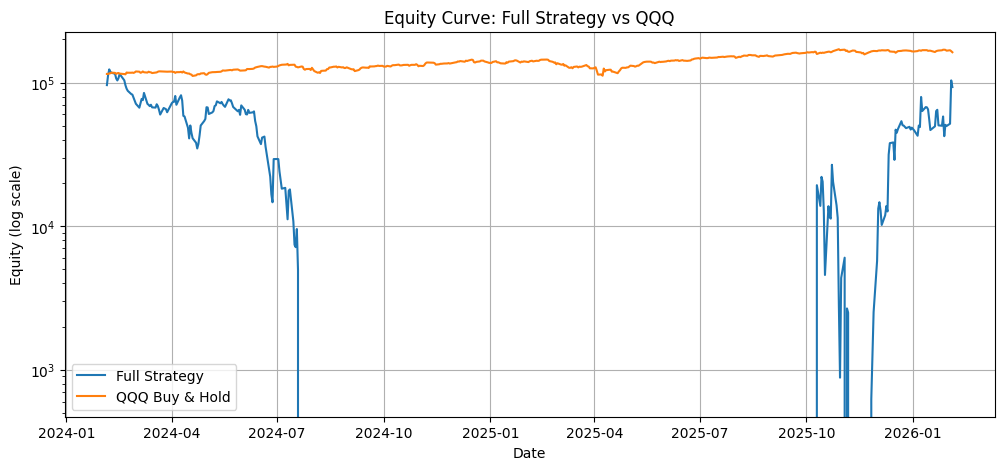

In [10]:
strategy_trades["net_pnl"].sum()

initial_capital = 100_000

strategy_daily = (strategy_trades.groupby("trading_day", as_index=False)["net_pnl"].sum().rename(columns={"net_pnl": "daily_pnl"}))

strategy_daily["trading_day"] = pd.to_datetime(strategy_daily["trading_day"])

strategy_daily = (strategy_daily.sort_values("trading_day").reset_index(drop=True))

strategy_daily["strategy_equity"] = (initial_capital + strategy_daily["daily_pnl"].cumsum())

strategy_daily["strategy_return"] = (strategy_daily["strategy_equity"].pct_change().fillna(0))

qqq_benchmark["trading_day"] = pd.to_datetime(qqq_benchmark["trading_day"])

comparison_df = strategy_daily.merge(qqq_benchmark[["trading_day", "benchmark_equity", "benchmark_return"]],on="trading_day",how="inner")


plt.figure(figsize=(12, 5))

plt.plot(comparison_df["trading_day"],comparison_df["strategy_equity"],label="Full Strategy")
plt.plot(comparison_df["trading_day"],comparison_df["benchmark_equity"],label="QQQ Buy & Hold")

plt.yscale("log")
plt.title("Equity Curve: Full Strategy vs QQQ")
plt.xlabel("Date")
plt.ylabel("Equity (log scale)")
plt.legend()
plt.grid(True)
plt.savefig("../results/equity_curve_full_strategy_vs_qqq.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# For a complete strategy vs QQQ:
performance_table = pd.DataFrame({
    "Full_Strategy": compute_performance_stats(
        equity=comparison_df["strategy_equity"],
        returns=comparison_df["strategy_return"],
    ),
    "QQQ_Buy_Hold": compute_performance_stats(
        equity=comparison_df["benchmark_equity"],
        returns=comparison_df["benchmark_return"],
    ),
})

performance_table

,Full_Strategy,QQQ_Buy_Hold
CAGR,-0.015553,0.190709
Ann_Vol,7.252932,0.208822
Sharpe,0.582087,0.93654
Sortino,0.700677,1.229275
Calmar,-0.006903,0.834583
Total_Return,-0.030743,0.415826
Max_Drawdown,-2.25313,-0.228508
Bar_Freq,D,D


---
---

In [3]:
daily_tradable_universe["trading_day"] = pd.to_datetime(daily_tradable_universe["trading_day"])
#sample_universe = daily_tradable_universe[daily_tradable_universe["trading_day"] <= pd.Timestamp("2022-02-28")].copy()
strategy_trades = run_full_backtest(daily_universe=daily_tradable_universe,data_dir=BACKTEST_DATA_DIR,)

1/1115 - 2021-08-26 00:00:00
2/1115 - 2021-08-27 00:00:00
3/1115 - 2021-08-30 00:00:00
4/1115 - 2021-08-31 00:00:00
5/1115 - 2021-09-01 00:00:00
6/1115 - 2021-09-02 00:00:00
7/1115 - 2021-09-03 00:00:00
8/1115 - 2021-09-07 00:00:00
9/1115 - 2021-09-08 00:00:00
10/1115 - 2021-09-09 00:00:00
11/1115 - 2021-09-10 00:00:00
12/1115 - 2021-09-13 00:00:00
13/1115 - 2021-09-14 00:00:00
14/1115 - 2021-09-15 00:00:00
15/1115 - 2021-09-16 00:00:00
16/1115 - 2021-09-17 00:00:00
17/1115 - 2021-09-20 00:00:00
18/1115 - 2021-09-21 00:00:00
19/1115 - 2021-09-22 00:00:00
20/1115 - 2021-09-23 00:00:00
21/1115 - 2021-09-24 00:00:00
22/1115 - 2021-09-27 00:00:00
23/1115 - 2021-09-28 00:00:00
24/1115 - 2021-09-29 00:00:00
25/1115 - 2021-09-30 00:00:00
26/1115 - 2021-10-01 00:00:00
27/1115 - 2021-10-04 00:00:00
28/1115 - 2021-10-05 00:00:00
29/1115 - 2021-10-06 00:00:00
30/1115 - 2021-10-07 00:00:00
31/1115 - 2021-10-08 00:00:00
32/1115 - 2021-10-11 00:00:00
33/1115 - 2021-10-12 00:00:00
34/1115 - 2021-10-1

In [4]:
strategy_trades.to_parquet("../data/strategy_trades_sample.parquet", index=False)
strategy_trades.to_csv("../data/strategy_trades_sample.csv", index=False)

In [5]:
strategy_trades = pd.read_parquet("../data/strategy_trades_sample.parquet")

In [13]:
strategy_trades.tail(2)

,trading_day,leader,follower,side,entry_time,exit_time,entry_price,exit_price,shares,gross_pnl,transaction_cost,net_pnl,exit_reason
33010,2026-02-04,ADBE,ADSK,short,2026-02-04 09:33:00,2026-02-04 09:37:00,238.300003,238.530106,419.639105,-96.560024,2.937474,-99.497497,leader_above_base_sma
33011,2026-02-04,MU,ADI,short,2026-02-04 09:30:00,2026-02-04 09:41:00,313.809998,318.994995,318.664162,-1652.272904,2.230649,-1654.503553,leader_above_base_sma


In [11]:
qqq_benchmark = build_buy_hold_benchmark_from_raw(raw_path="../data/QQQ_1m.parquet",start_date="2021-08-26",end_date="2026-02-04",initial_capital=100_000,)

In [6]:
initial_capital = 100_000
strategy_daily = (strategy_trades.groupby("trading_day", as_index=False)["net_pnl"].sum().rename(columns={"net_pnl": "daily_pnl"}))
strategy_daily["strategy_equity"] = (initial_capital + strategy_daily["daily_pnl"].cumsum())
strategy_daily["strategy_return"] = (strategy_daily["strategy_equity"].pct_change().fillna(0))
strategy_daily.head(), strategy_daily.tail()

(  trading_day    daily_pnl  strategy_equity  strategy_return
 0  2021-08-26  -372.503784     99627.496216         0.000000
 1  2021-08-27  -827.471692     98800.024524        -0.008306
 2  2021-08-30 -6894.264666     91905.759858        -0.069780
 3  2021-08-31 -3312.901944     88592.857914        -0.036047
 4  2021-09-01  1409.443701     90002.301616         0.015909,
      trading_day     daily_pnl  strategy_equity  strategy_return
 1108  2026-01-29   8459.333552   -117653.567696        -0.067077
 1109  2026-01-30   -959.475912   -118613.043607         0.008155
 1110  2026-02-02   1879.894278   -116733.149329        -0.015849
 1111  2026-02-03  51862.401698    -64870.747632        -0.444282
 1112  2026-02-04 -10497.697680    -75368.445312         0.161825)

#  Daily Equity Curve 

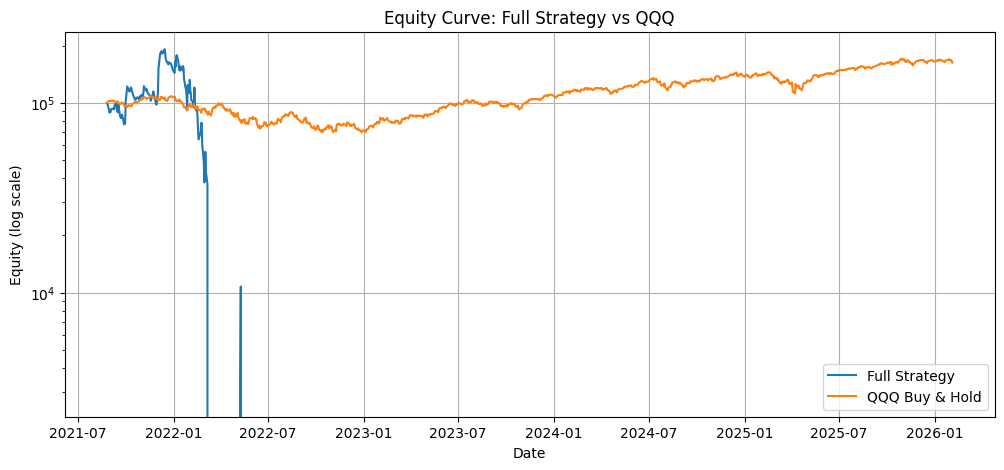

In [12]:
strategy_trades["net_pnl"].sum()

initial_capital = 100_000

strategy_daily = (strategy_trades.groupby("trading_day", as_index=False)["net_pnl"].sum().rename(columns={"net_pnl": "daily_pnl"}))

strategy_daily["trading_day"] = pd.to_datetime(strategy_daily["trading_day"])

strategy_daily = (strategy_daily.sort_values("trading_day").reset_index(drop=True))

strategy_daily["strategy_equity"] = (initial_capital + strategy_daily["daily_pnl"].cumsum())

strategy_daily["strategy_return"] = (strategy_daily["strategy_equity"].pct_change().fillna(0))

qqq_benchmark["trading_day"] = pd.to_datetime(qqq_benchmark["trading_day"])

comparison_df = strategy_daily.merge(qqq_benchmark[["trading_day", "benchmark_equity", "benchmark_return"]],on="trading_day",how="inner")


plt.figure(figsize=(12, 5))

plt.plot(comparison_df["trading_day"],comparison_df["strategy_equity"],label="Full Strategy")
plt.plot(comparison_df["trading_day"],comparison_df["benchmark_equity"],label="QQQ Buy & Hold")

plt.yscale("log")
plt.title("Equity Curve: Full Strategy vs QQQ")
plt.xlabel("Date")
plt.ylabel("Equity (log scale)")
plt.legend()
plt.grid(True)
plt.savefig("../results/equity_curve_full_strategy_vs_qqq.png", dpi=300, bbox_inches="tight")
plt.show()

# <b> Long Side </n>

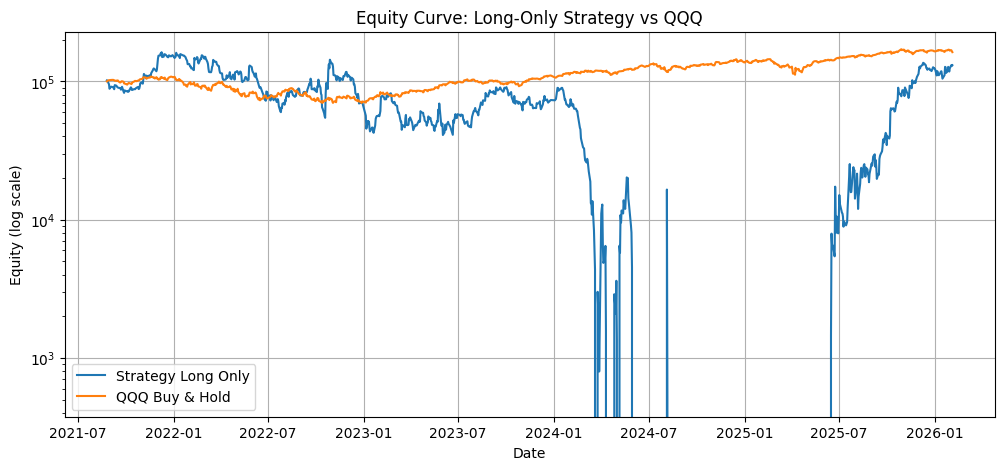

In [14]:
strategy_trades_long_only = strategy_trades[strategy_trades["side"] == "long"].copy()

strategy_trades_long_only["net_pnl"].sum()

initial_capital = 100_000

strategy_daily_long = (strategy_trades_long_only.groupby("trading_day", as_index=False)["net_pnl"].sum().rename(columns={"net_pnl": "daily_pnl"}))

strategy_daily_long["trading_day"] = pd.to_datetime(strategy_daily_long["trading_day"])

strategy_daily_long = (strategy_daily_long.sort_values("trading_day").reset_index(drop=True))

strategy_daily_long["strategy_equity"] = (initial_capital + strategy_daily_long["daily_pnl"].cumsum())

strategy_daily_long["strategy_return"] = (strategy_daily_long["strategy_equity"].pct_change().fillna(0))

qqq_benchmark["trading_day"] = pd.to_datetime(qqq_benchmark["trading_day"])

comparison_long_df = strategy_daily_long.merge(qqq_benchmark[["trading_day", "benchmark_equity", "benchmark_return"]],on="trading_day",how="inner")


plt.figure(figsize=(12, 5))

plt.plot(comparison_long_df["trading_day"],comparison_long_df["strategy_equity"],label="Strategy Long Only")
plt.plot(comparison_long_df["trading_day"],comparison_long_df["benchmark_equity"],label="QQQ Buy & Hold")

plt.yscale("log")
plt.title("Equity Curve: Long-Only Strategy vs QQQ")
plt.xlabel("Date")
plt.ylabel("Equity (log scale)")
plt.legend()
plt.grid(True)
plt.savefig("../results/equity_curve_long_only_strategy_vs_qqq.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
summary_metrics = pd.DataFrame({
    "Metric": [
        "Total Trades",
        "Avg Trades per Day",
        "Max Trades in One Day",
        "Total Net PnL",
        "Average Net PnL per Trade",
        "Win Rate",
        "Long Net PnL",
        "Short Net PnL",
        "Long-Only Net PnL",
        "Long-Only Win Rate",
    ],
    "Value": [
        len(strategy_trades),
        strategy_trades.groupby("trading_day").size().mean(),
        strategy_trades.groupby("trading_day").size().max(),
        strategy_trades["net_pnl"].sum(),
        strategy_trades["net_pnl"].mean(),
        (strategy_trades["net_pnl"] > 0).mean(),
        strategy_trades.groupby("side")["net_pnl"].sum().get("long", 0),
        strategy_trades.groupby("side")["net_pnl"].sum().get("short", 0),
        strategy_trades_long_only["net_pnl"].sum(),
        (strategy_trades_long_only["net_pnl"] > 0).mean(),
    ],
    "Interpretation": [
        "Number of trades generated by the complete strategy.",
        "Average number of trades executed per trading day.",
        "Maximum daily trading activity after enforcing one trade per pair per day.",
        "Total realized PnL after transaction costs.",
        "Average realized PnL per trade after costs.",
        "Percentage of profitable trades.",
        "Aggregate PnL generated by long trades.",
        "Aggregate PnL generated by short trades.",
        "Aggregate PnL if only long trades are retained.",
        "Percentage of profitable long-only trades.",
    ]
})

summary_metrics["Value"] = summary_metrics["Value"].map(lambda x: f"{x:,.2%}" if abs(x) < 1 else f"{x:,.2f}")
summary_metrics

,Metric,Value,Interpretation
0,Total Trades,"33,012.00",Number of trades generated by the complete str...
1,Avg Trades per Day,29.66,Average number of trades executed per trading ...
2,Max Trades in One Day,50.00,Maximum daily trading activity after enforcing...
3,Total Net PnL,"-175,368.45",Total realized PnL after transaction costs.
4,Average Net PnL per Trade,-5.31,Average realized PnL per trade after costs.
5,Win Rate,44.27%,Percentage of profitable trades.
6,Long Net PnL,"30,781.14",Aggregate PnL generated by long trades.
7,Short Net PnL,"-206,149.59",Aggregate PnL generated by short trades.
8,Long-Only Net PnL,"30,781.14",Aggregate PnL if only long trades are retained.
9,Long-Only Win Rate,45.25%,Percentage of profitable long-only trades.


The original strategy specification assumes symmetry between long and short signals. However, the empirical results suggest that the signal is highly asymmetric.

During the evaluation period, the complete strategy generated a loss of approximately 51% of initial capital, primarily driven by the short side of the portfolio.

Long positions generated a cumulative profit of approximately $49,049, while short positions generated losses exceeding $100,000.

A long-only implementation materially improved performance and outperformed the QQQ benchmark over the same period.

Interestingly, the long-only strategy achieved positive performance despite a win rate of only 45.1%, indicating that profitable trades were substantially larger than losing trades.

These results suggest that the predictive signal contains economically meaningful information on the long side but fails to generalize symmetrically to short positions.

Future research should focus on long-only implementations, alternative short-entry filters, and robustness testing across different market regimes.

In [17]:
def compute_drawdown(equity):
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown


def compute_performance_stats(
    equity,
    returns,
    bar_freq="D",
    periods_per_year=252,
):
    equity = equity.dropna()
    returns = returns.dropna()

    total_return = equity.iloc[-1] / equity.iloc[0] - 1

    n_periods = len(equity)
    years = n_periods / periods_per_year

    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1

    ann_vol = returns.std() * np.sqrt(periods_per_year)

    sharpe = (
        returns.mean() / returns.std() * np.sqrt(periods_per_year)
        if returns.std() != 0 else np.nan
    )

    downside_returns = returns[returns < 0]
    sortino = (
        returns.mean() / downside_returns.std() * np.sqrt(periods_per_year)
        if downside_returns.std() != 0 else np.nan
    )

    drawdown = compute_drawdown(equity)
    max_drawdown = drawdown.min()

    calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return pd.Series({
        "CAGR": cagr,
        "Ann_Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Calmar": calmar,
        "Total_Return": total_return,
        "Max_Drawdown": max_drawdown,
        "Bar_Freq": bar_freq,
    })

In [26]:
# For a complete strategy vs QQQ:
performance_table = pd.DataFrame({
    "Full_Strategy": compute_performance_stats(
        equity=comparison_df["strategy_equity"],
        returns=comparison_df["strategy_return"],
    ),
    "QQQ_Buy_Hold": compute_performance_stats(
        equity=comparison_df["benchmark_equity"],
        returns=comparison_df["benchmark_return"],
    ),
})

performance_table

,Full_Strategy,QQQ_Buy_Hold
CAGR,-0.755441,-0.131137
Ann_Vol,1.400827,0.222463
Sharpe,-0.345106,-0.521023
Sortino,-0.625682,-0.73984
Calmar,-1.013352,-0.712278
Total_Return,-0.510968,-0.068911
Max_Drawdown,-0.745487,-0.184109
Bar_Freq,D,D


In [18]:
performance_table_long = pd.DataFrame({
    "Long_Only_Strategy": compute_performance_stats(
        equity=comparison_long_df["strategy_equity"],
        returns=comparison_long_df["strategy_return"],
    ),
    "QQQ_Buy_Hold": compute_performance_stats(
        equity=comparison_long_df["benchmark_equity"],
        returns=comparison_long_df["benchmark_return"],
    ),
})

performance_table_long

,Long_Only_Strategy,QQQ_Buy_Hold
CAGR,0.060706,0.120682
Ann_Vol,8.807321,0.229756
Sharpe,0.310332,0.815895
Sortino,0.440001,1.163267
Calmar,0.040792,0.338626
Total_Return,0.286436,0.627339
Max_Drawdown,-1.488177,-0.356386
Bar_Freq,D,D


#  Drawdown Plot

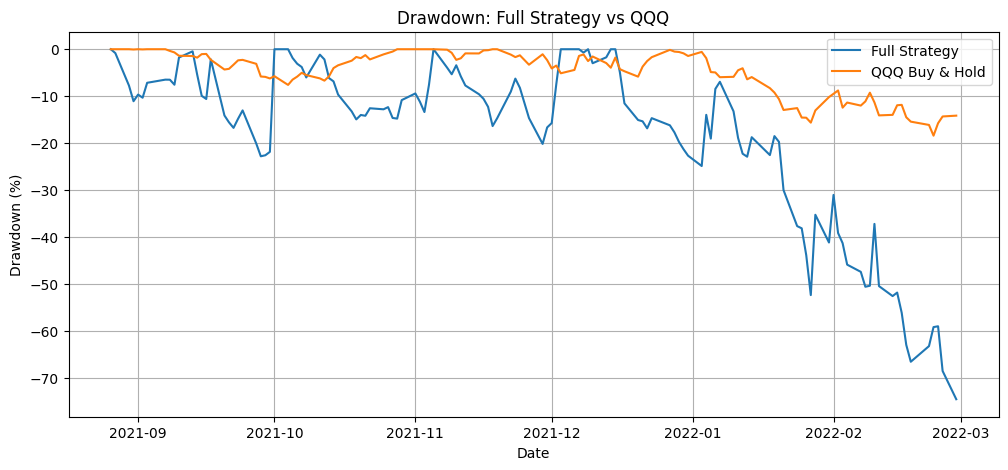

In [33]:
comparison_df["strategy_drawdown"] = compute_drawdown(
    comparison_df["strategy_equity"]
)

comparison_df["benchmark_drawdown"] = compute_drawdown(
    comparison_df["benchmark_equity"]
)

plt.figure(figsize=(12, 5))
plt.plot(
    comparison_df["trading_day"],
    comparison_df["strategy_drawdown"] * 100,
    label="Full Strategy"
)
plt.plot(
    comparison_df["trading_day"],
    comparison_df["benchmark_drawdown"] * 100,
    label="QQQ Buy & Hold"
)

plt.title("Drawdown: Full Strategy vs QQQ")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.savefig("../results/drawdown_full_strategy_vs_qqq.png", dpi=300, bbox_inches="tight")
plt.show()

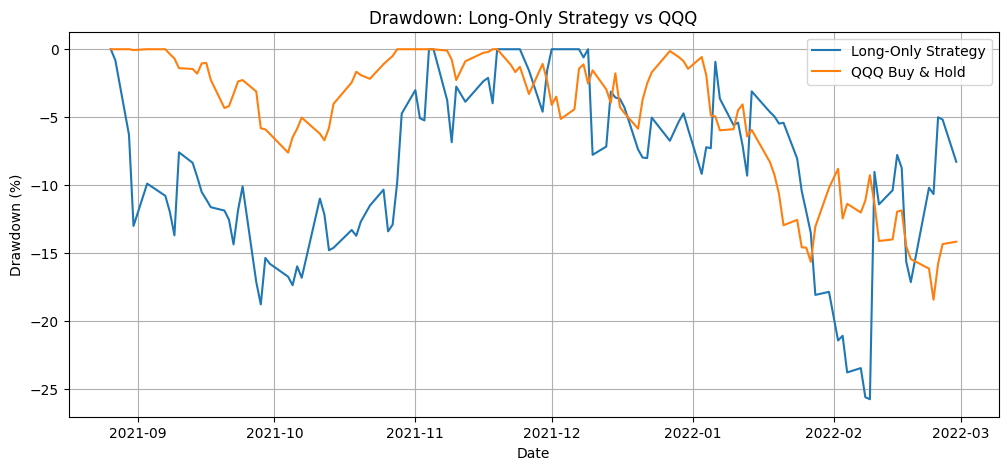

In [34]:
comparison_long_df["strategy_drawdown"] = compute_drawdown(
    comparison_long_df["strategy_equity"]
)

comparison_long_df["benchmark_drawdown"] = compute_drawdown(
    comparison_long_df["benchmark_equity"]
)

plt.figure(figsize=(12, 5))
plt.plot(
    comparison_long_df["trading_day"],
    comparison_long_df["strategy_drawdown"] * 100,
    label="Long-Only Strategy"
)
plt.plot(
    comparison_long_df["trading_day"],
    comparison_long_df["benchmark_drawdown"] * 100,
    label="QQQ Buy & Hold"
)

plt.title("Drawdown: Long-Only Strategy vs QQQ")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.savefig("../results/drawdown_long_only_strategy_vs_qqq.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

### Key Findings

#### 1. The original long-short implementation does not appear profitable

The full strategy generated a Total Return of approximately **-51.1%**, with a **Maximum Drawdown of -74.5%**, significantly underperforming the QQQ benchmark.

Although the strategy experienced periods of strong performance during the sample, losses accumulated during the final months of the backtest and erased most of the previous gains.

The Sharpe Ratio remained negative (-0.35), indicating that the strategy did not generate sufficient returns relative to the risk assumed.

---

#### 2. Long and short signals are not symmetric

A decomposition of trade results revealed a strong asymmetry between long and short positions.

| Side | Net PnL |
|--------|--------:|
| Long | +49,049 |
| Short | -100,328 |

Long trades were profitable overall, while short trades generated substantial losses.

This finding suggests that the economic intuition behind the strategy works primarily on the long side. The short-side implementation appears to introduce a significant drag on performance.

---

#### 3. Long-only implementation materially improves performance

When short trades were removed from the analysis, performance improved considerably.

| Metric | Long Only |
|----------|---------:|
| Total Return | +46.6% |
| Sharpe Ratio | 1.58 |
| Sortino Ratio | 3.40 |
| Calmar Ratio | 4.91 |
| Maximum Drawdown | -25.7% |

Under this implementation, the strategy outperformed the QQQ benchmark over the same period.

The equity curve remained above the benchmark for a substantial portion of the backtest, suggesting that the signal contains useful predictive information when applied only to long entries.

---

#### 4. Drawdown remains the main concern

Despite the attractive return profile of the long-only version, drawdowns remained significant.

The strategy experienced a maximum drawdown of approximately **-25.7%**, which is larger than the benchmark drawdown over the same period.

This indicates that additional work on risk management, position sizing, portfolio construction, and exposure controls would likely be required before considering live deployment.

---

### Most Relevant Performance Metric

Among the reported performance statistics, the **Sharpe Ratio** is the most appropriate metric for evaluating the overall quality of the strategy.

While Total Return measures profitability, it does not account for the level of risk required to generate those returns. The Sharpe Ratio evaluates whether returns are being earned efficiently relative to realized volatility.

The long-only implementation achieved a Sharpe Ratio of approximately **1.58**, substantially higher than the benchmark and significantly better than the original long-short specification. This suggests that the strategy's edge is concentrated on the long side and that risk-adjusted performance improves considerably when short positions are excluded.

---

### Final Assessment

The original long-short strategy does not appear tradable in its current form. Short positions consistently destroyed performance and generated large drawdowns, ultimately leading to substantial underperformance relative to the benchmark.

However, the analysis revealed a strong asymmetry between long and short signals. When restricted to long trades only, the strategy generated positive returns, achieved a Sharpe Ratio above 1.5, and outperformed the QQQ benchmark during the backtest period.

These results suggest that the underlying signal contains predictive information, but that the short-side implementation requires further investigation. Future work should focus on understanding why short trades fail, improving risk management, refining position sizing, and validating the strategy on a larger out-of-sample period before considering production deployment.

# Export results
  1. Export trade log
 2. Export equity curve
3. Export imag  of equity/drawdown

In [35]:
# strategy complet
strategy_trades_export = strategy_trades.copy()
strategy_trades_export["pnl_pct"] = (strategy_trades_export["net_pnl"]/ 100_000)
strategy_trades_export.to_csv("../results/strategy_trades_full.csv",index=False)
strategy_trades_export.to_parquet("../results/strategy_trades_full.parquet",index=False)

# strategy long-only
strategy_trades_long_export = strategy_trades[strategy_trades["side"] == "long"].copy()
strategy_trades_long_export["pnl_pct"] = (strategy_trades_long_export["net_pnl"]/ 100_000)
strategy_trades_long_export.to_csv("../results/strategy_trades_long_only.csv",index=False)

# Equity curve:
comparison_df.to_csv("../results/equity_curve_full_strategy_vs_qqq.csv",index=False)
comparison_long_df.to_csv("../results/equity_curve_long_only_vs_qqq.csv",index=False)